In [1]:
!pip install contextily

In [2]:
# packages
from google.colab import files
import io
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import seaborn as sns
import contextily as ctx
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches

In [3]:
sopp_df = pd.read_csv('sopp_df_3_8.csv')

/tmp/ipykernel_6336/3186061821.py:1: DtypeWarning: Columns (8,10,17,18,19,24,25,26,27,31,32,33,34,35,37,38,39,40,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  sopp_df = pd.read_csv('sopp_df_3_8.csv')


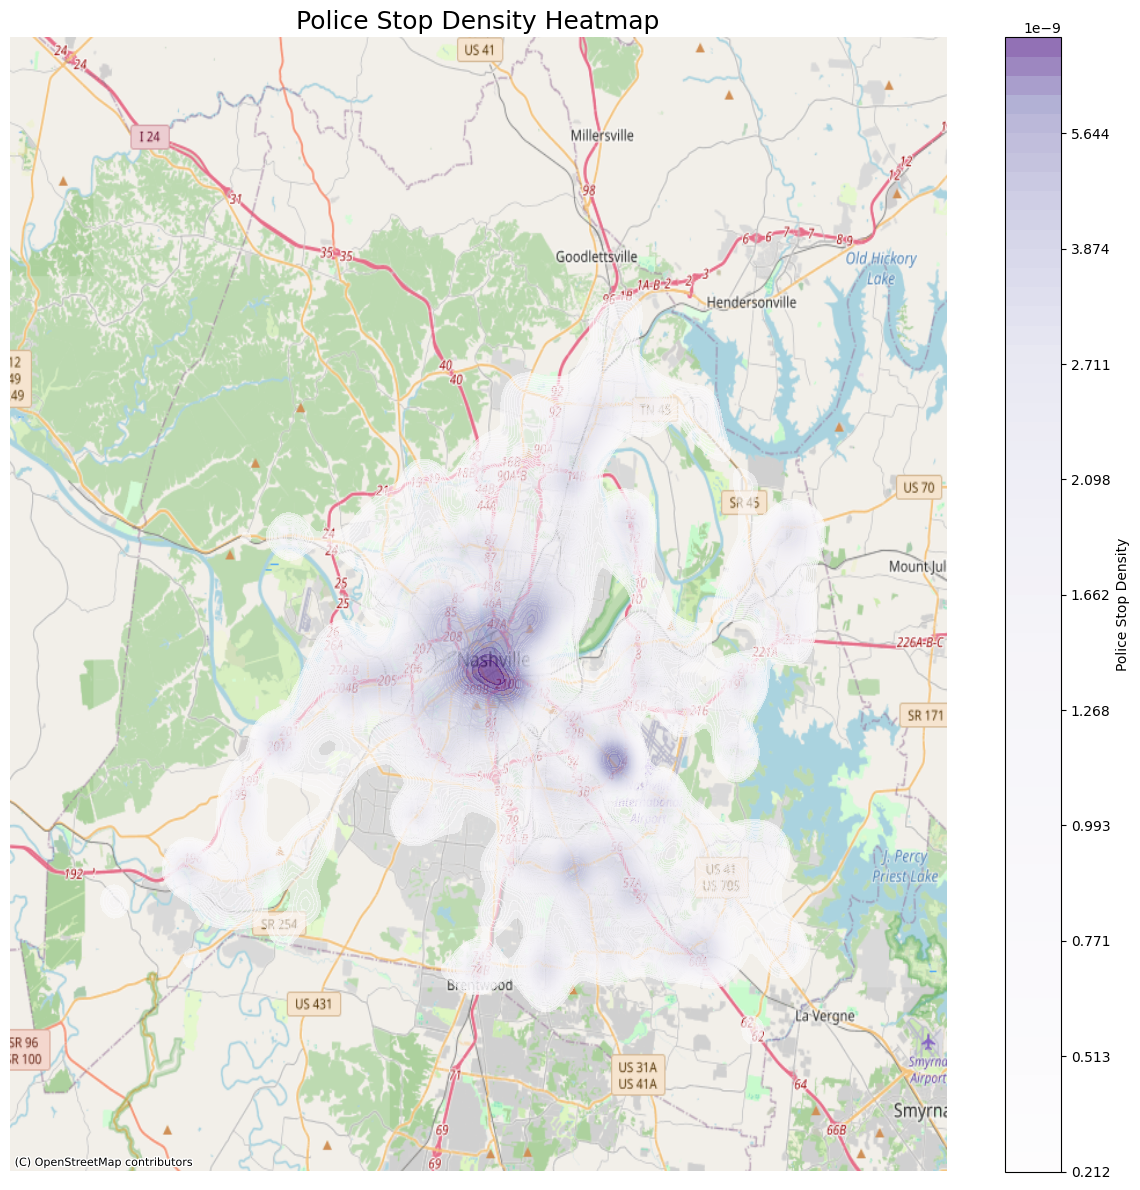

In [4]:
gdf = gpd.GeoDataFrame(
    sopp_df,
    geometry=gpd.points_from_xy(sopp_df.lng, sopp_df.lat),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)

x = gdf_web_mercator.geometry.x
y = gdf_web_mercator.geometry.y

fig, ax = plt.subplots(figsize=(12, 12))

kde = sns.kdeplot(
    data=gdf_web_mercator,
    x=gdf_web_mercator.geometry.x,
    y=gdf_web_mercator.geometry.y,
    fill=True,
    cmap="Purples",
    levels=60,
    alpha=0.6,
    cbar=True,
    ax=ax
)

cbar = kde.collections[0].colorbar
cbar.set_label("Police Stop Density")
cbar.formatter.set_powerlimits((0,0))
cbar.update_ticks()

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Police Stop Density Heatmap", fontsize=18)
plt.tight_layout()

plt.show()